In [2]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, hamming_loss
from sklearn.preprocessing import MultiLabelBinarizer
import joblib
from sklearn.ensemble import VotingClassifier

In [3]:
def load_and_clean_data(filepath):
    print(f"Loading data from {filepath}...")
    df = pd.read_csv(filepath)
    
    # Basic EDA: Print shape before cleaning
    print(f"Initial shape: {df.shape}")
    
    # Check for correct column names and determine which one exists
    if 'dependencies_found' in df.columns:
        dep_col = 'dependencies_found'
    elif 'dependecies_found' in df.columns:
        dep_col = 'dependecies_found'
    else:
        raise ValueError("Cannot find dependencies column (tried 'dependencies_found' and 'dependecies_found')")
    
    print(f"Using dependency column: '{dep_col}'")
    
    # Remove rows with empty dependencies or label
    df = df.dropna(subset=[dep_col, 'dependency_labels'])
    df = df[df[dep_col].str.strip() != '']
    df = df[df['dependency_labels'].str.strip() != '']
    
    print(f"Shape after cleaning: {df.shape}")
    return df, dep_col

def parse_dependencies(dep_str):
    try:
        if isinstance(dep_str, str) and dep_str.strip().startswith('['):
            return ast.literal_eval(dep_str)
        elif isinstance(dep_str, str):
            return [x.strip() for x in dep_str.split(',') if x.strip()]
        return []
    except Exception as e:
        return []

def parse_labels(label_str):
    try:
        # Handle list string format like "['Label1', 'Label2']"
        if isinstance(label_str, str) and label_str.strip().startswith('['):
            return ast.literal_eval(label_str)
        elif isinstance(label_str, str):
            return [x.strip() for x in label_str.split(',') if x.strip()]
        return []
    except Exception as e:
        return []

In [4]:
# 1. Load and Clean Main Data
main_file = 'joss_all_with_dependency_labels1.csv'
lookup_file = 'dependency_counts_with_labels.csv'

df, dep_col = load_and_clean_data(main_file)
print(f"Using dependency column: '{dep_col}'")

Loading data from joss_all_with_dependency_labels1.csv...
Initial shape: (3199, 27)
Using dependency column: 'dependecies_found'
Shape after cleaning: (1559, 27)
Using dependency column: 'dependecies_found'


In [5]:
# 2. Load Lookup Data to define vocabulary
print(f"Loading lookup table from {lookup_file}...")
try:
    lookup_df = pd.read_csv(lookup_file)
    valid_dependencies = set(lookup_df['dependency'].dropna().astype(str).str.strip().unique())
    valid_labels = set(lookup_df['label'].dropna().astype(str).str.strip().unique())
    print(f"Found {len(valid_dependencies)} valid dependencies and {len(valid_labels)} valid labels in lookup.")
    
    # Print the valid labels in a formatted way
    print(f"\nValid Labels ({len(valid_labels)}):")
    for i, label in enumerate(sorted(valid_labels), 1):
        print(f"  {i:3d}. {label}")
    
except Exception as e:
    print(f"Error loading lookup file: {e}")

Loading lookup table from dependency_counts_with_labels.csv...
Found 6562 valid dependencies and 9 valid labels in lookup.

Valid Labels (9):
    1. Data analytics
    2. Hardware
    3. Integrative analysis
    4. Modeling and simulation
    5. Process
    6. RIS
    7. Software
    8. Software analytics
    9. UI


In [6]:
# 3. Feature Extraction and Preprocessing
print("Extracting features...")

# Process Dependencies
df['dep_list'] = df[dep_col].apply(parse_dependencies)
# Normalize dependencies (lowercase) for better matching
df['dep_list'] = df['dep_list'].apply(lambda x: [str(d).lower() for d in x])
valid_dependencies_lower = {str(d).lower() for d in valid_dependencies}

df['filtered_deps'] = df['dep_list'].apply(lambda x: [dep for dep in x if dep in valid_dependencies_lower])

# Process Labels (Multi-label)
df['label_list'] = df['dependency_labels'].apply(parse_labels)
# Normalize labels (title case or lower case) to match lookup
# Assuming lookup labels are Title Case or similar. Let's normalize both to be safe.
valid_labels_norm = {str(l).strip() for l in valid_labels}

# Function to check if label is in valid set (fuzzy or exact)
def filter_labels(labels, valid_set):
    filtered = []
    for l in labels:
        l_str = str(l).strip()
        # Try exact match
        if l_str in valid_set:
            filtered.append(l_str)
        # Try case insensitive
        else:
            for v in valid_set:
                if l_str.lower() == v.lower():
                    filtered.append(v)
                    break
    return list(set(filtered)) # Remove duplicates

df['filtered_labels'] = df['label_list'].apply(lambda x: filter_labels(x, valid_labels_norm))

# Filter out rows with no valid dependencies or labels after filtering
df = df[df['filtered_deps'].map(len) > 0]
df = df[df['filtered_labels'].map(len) > 0]

print(f"Shape after filtering by lookup: {df.shape}")

if df.empty:
    print("No data left after filtering. Check if lookup file matches data.")
else:
    # X: Dependencies
    mlb_X = MultiLabelBinarizer(classes=sorted(list(valid_dependencies_lower)))
    X = mlb_X.fit_transform(df['filtered_deps'])

    # y: Labels
    # Re-fit MLB on the actually present labels in the filtered data to avoid empty classes if any
    present_labels = set([l for sublist in df['filtered_labels'] for l in sublist])
    mlb_y = MultiLabelBinarizer(classes=sorted(list(present_labels)))
    y = mlb_y.fit_transform(df['filtered_labels'])

    print(f"Feature matrix shape: {X.shape}")
    print(f"Label matrix shape: {y.shape}")

Extracting features...
Shape after filtering by lookup: (1559, 31)
Feature matrix shape: (1559, 6364)
Label matrix shape: (1559, 9)


Visualizing data distributions and Class Imbalance...

--- Label Statistics (Global) ---
Total Unique Labels: 9
Most Frequent Label: 'Software' (1360 occurrences)
Least Frequent Label: 'Integrative analysis' (43 occurrences)

--- Per-Repository Statistics (Cardinality) ---
Avg Labels per Repo: 4.50 (Median: 5.0)
Max Labels in a Repo: 9
Avg Dependencies per Repo: 26.00 (Median: 14.0)
Max Dependencies in a Repo: 353

--- Class Imbalance Insights ---
Top 5 Labels account for 82.29% of all label assignments.
Bottom 50% of labels account for 17.71% of all label assignments.



C:\Users\eggoni\AppData\Local\Temp\ipykernel_25964\449195808.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.head(20).values, y=label_counts.head(20).index, palette='viridis')
C:\Users\eggoni\AppData\Local\Temp\ipykernel_25964\449195808.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bottom_20.values, y=bottom_20.index, palette='rocket')


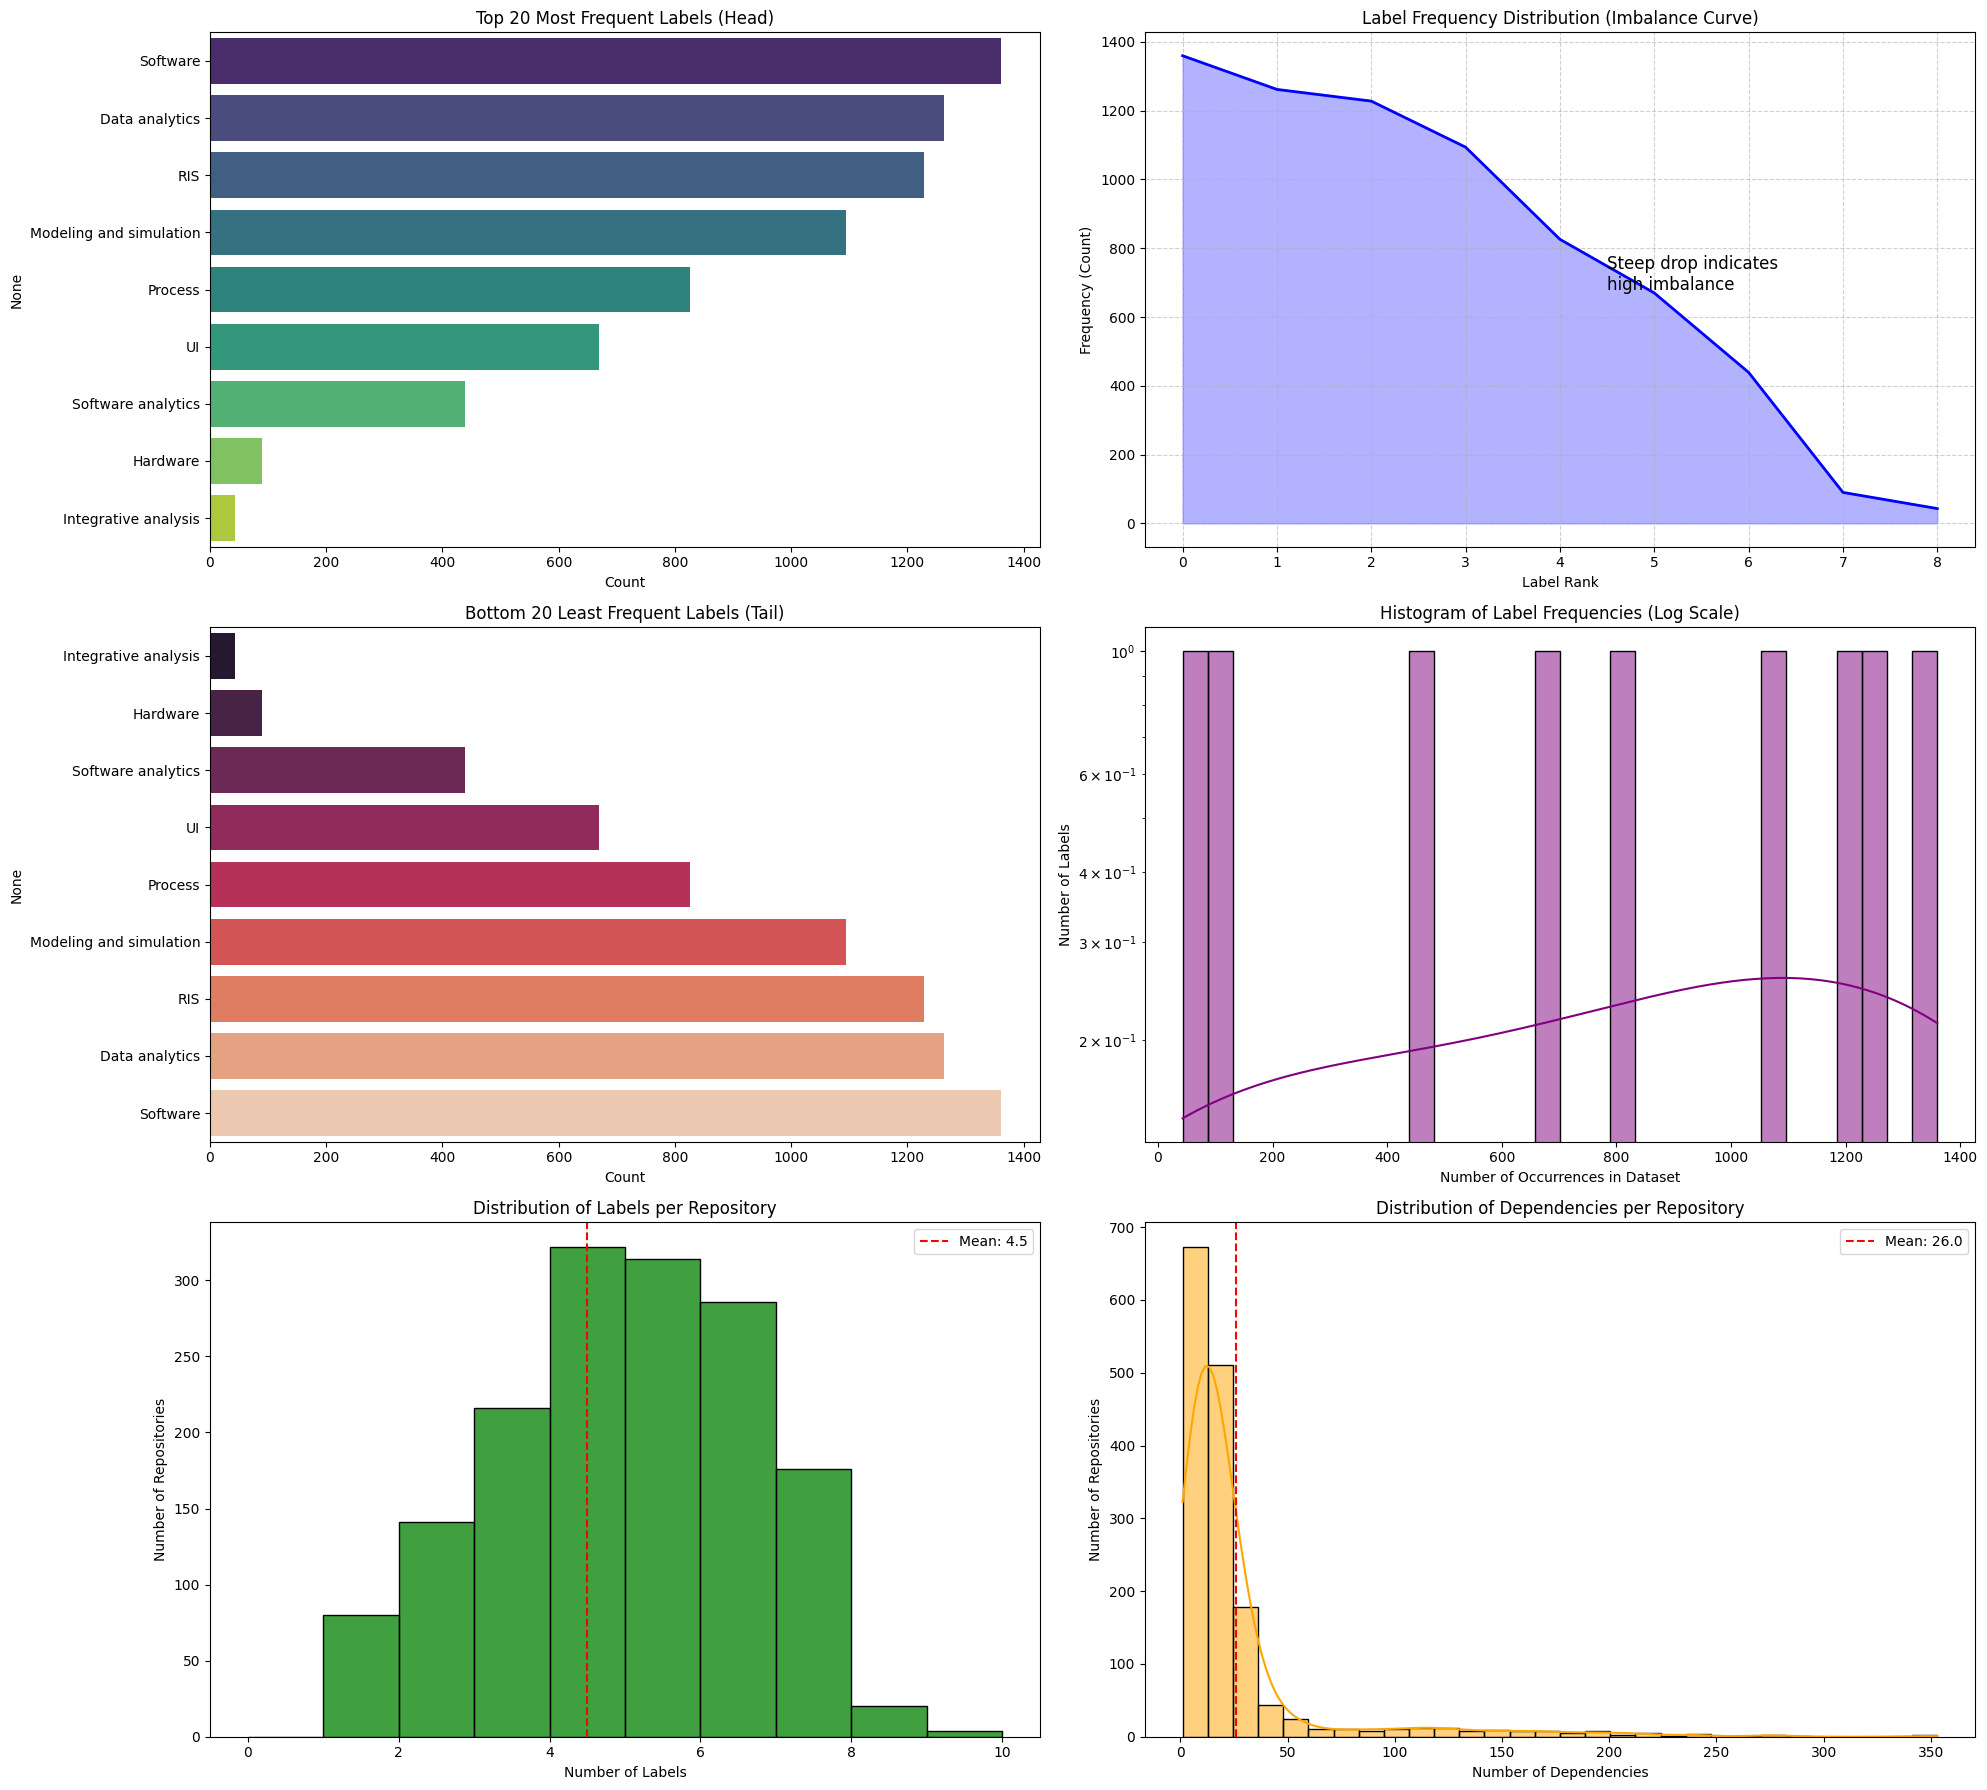

In [7]:
# 3.5 Data Visualization and Imbalance Analysis
if not df.empty:
    print("Visualizing data distributions and Class Imbalance...")
    
    # Flatten lists to count occurrences (Global Stats)
    all_labels = [label for sublist in df['filtered_labels'] for label in sublist]
    all_deps = [dep for sublist in df['filtered_deps'] for dep in sublist]
    
    # Per-Repository Counts (Row-wise Stats)
    labels_per_repo = df['filtered_labels'].apply(len)
    deps_per_repo = df['filtered_deps'].apply(len)
    
    label_counts = pd.Series(all_labels).value_counts()
    dep_counts = pd.Series(all_deps).value_counts()
    
    n_unique_labels = len(label_counts)
    
    # --- Text Statistics ---
    print(f"\n{'='*40}")
    print(f"--- Label Statistics (Global) ---")
    print(f"Total Unique Labels: {n_unique_labels}")
    print(f"Most Frequent Label: '{label_counts.index[0]}' ({label_counts.iloc[0]} occurrences)")
    print(f"Least Frequent Label: '{label_counts.index[-1]}' ({label_counts.iloc[-1]} occurrences)")
    
    print(f"\n--- Per-Repository Statistics (Cardinality) ---")
    print(f"Avg Labels per Repo: {labels_per_repo.mean():.2f} (Median: {labels_per_repo.median()})")
    print(f"Max Labels in a Repo: {labels_per_repo.max()}")
    print(f"Avg Dependencies per Repo: {deps_per_repo.mean():.2f} (Median: {deps_per_repo.median()})")
    print(f"Max Dependencies in a Repo: {deps_per_repo.max()}")
    
    # Identify Imbalance
    print("\n--- Class Imbalance Insights ---")
    print(f"Top 5 Labels account for {label_counts.head(5).sum() / label_counts.sum() * 100:.2f}% of all label assignments.")
    if n_unique_labels > 1:
        print(f"Bottom 50% of labels account for {label_counts.tail(int(n_unique_labels/2)).sum() / label_counts.sum() * 100:.2f}% of all label assignments.")
    print(f"{'='*40}\n")

    # --- Visualization ---
    plt.figure(figsize=(20, 18)) # Increased height for 3 rows
    
    # 1. Top 20 Labels
    plt.subplot(3, 2, 1)
    sns.barplot(x=label_counts.head(20).values, y=label_counts.head(20).index, palette='viridis')
    plt.title(f'Top 20 Most Frequent Labels (Head)')
    plt.xlabel('Count')
    
    # 2. Label Frequency Distribution (Long Tail)
    plt.subplot(3, 2, 2)
    # Plot the sorted counts of all labels
    plt.plot(range(len(label_counts)), label_counts.values, color='blue', linewidth=2)
    plt.fill_between(range(len(label_counts)), label_counts.values, color='blue', alpha=0.3)
    plt.title('Label Frequency Distribution (Imbalance Curve)')
    plt.xlabel('Label Rank')
    plt.ylabel('Frequency (Count)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.text(len(label_counts)*0.5, label_counts.max()*0.5, 'Steep drop indicates\nhigh imbalance', fontsize=12)

    # 3. Bottom 20 Labels (Rare Classes)
    plt.subplot(3, 2, 3)
    # Take the tail, but sort ascending for plotting
    bottom_20 = label_counts.tail(20).sort_values(ascending=True) 
    sns.barplot(x=bottom_20.values, y=bottom_20.index, palette='rocket')
    plt.title('Bottom 20 Least Frequent Labels (Tail)')
    plt.xlabel('Count')
    
    # 4. Histogram of Label Counts (How many labels have X samples?)
    plt.subplot(3, 2, 4)
    sns.histplot(label_counts, bins=30, kde=True, color='purple')
    plt.title('Histogram of Label Frequencies (Log Scale)')
    plt.xlabel('Number of Occurrences in Dataset')
    plt.ylabel('Number of Labels')
    plt.yscale('log') # Log scale to see the rare ones better
    
    # 5. Distribution of Labels per Repository (Multi-label Cardinality)
    plt.subplot(3, 2, 5)
    sns.histplot(labels_per_repo, bins=range(0, labels_per_repo.max() + 2), kde=False, color='green')
    plt.title('Distribution of Labels per Repository')
    plt.xlabel('Number of Labels')
    plt.ylabel('Number of Repositories')
    plt.axvline(labels_per_repo.mean(), color='red', linestyle='--', label=f'Mean: {labels_per_repo.mean():.1f}')
    plt.legend()

    # 6. Distribution of Dependencies per Repository
    plt.subplot(3, 2, 6)
    sns.histplot(deps_per_repo, bins=30, kde=True, color='orange')
    plt.title('Distribution of Dependencies per Repository')
    plt.xlabel('Number of Dependencies')
    plt.ylabel('Number of Repositories')
    plt.axvline(deps_per_repo.mean(), color='red', linestyle='--', label=f'Mean: {deps_per_repo.mean():.1f}')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

Visualizing data distributions and Class Imbalance...

--- Label Statistics (Global) ---
Total Unique Labels: 9
Most Frequent Label: 'Software' (1360 occurrences)
Least Frequent Label: 'Integrative analysis' (43 occurrences)

--- Per-Repository Statistics (Cardinality) ---
Avg Labels per Repo: 4.50 (Median: 5.0)
Max Labels in a Repo: 9
Avg Dependencies per Repo: 26.00 (Median: 14.0)
Max Dependencies in a Repo: 353

--- Class Imbalance Insights ---
Top 5 Labels account for 82.29% of all label assignments.
Bottom 50% of labels account for 17.71% of all label assignments.



C:\Users\eggoni\AppData\Local\Temp\ipykernel_25964\3553405979.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.head(20).values, y=label_counts.head(20).index, palette='viridis')


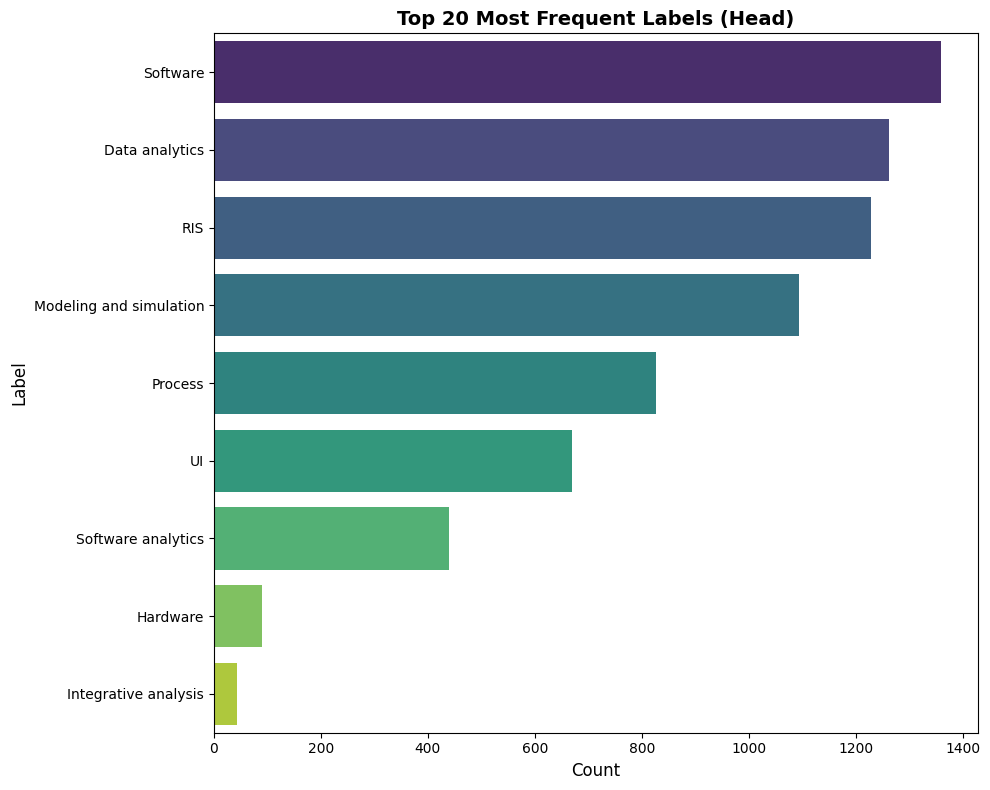

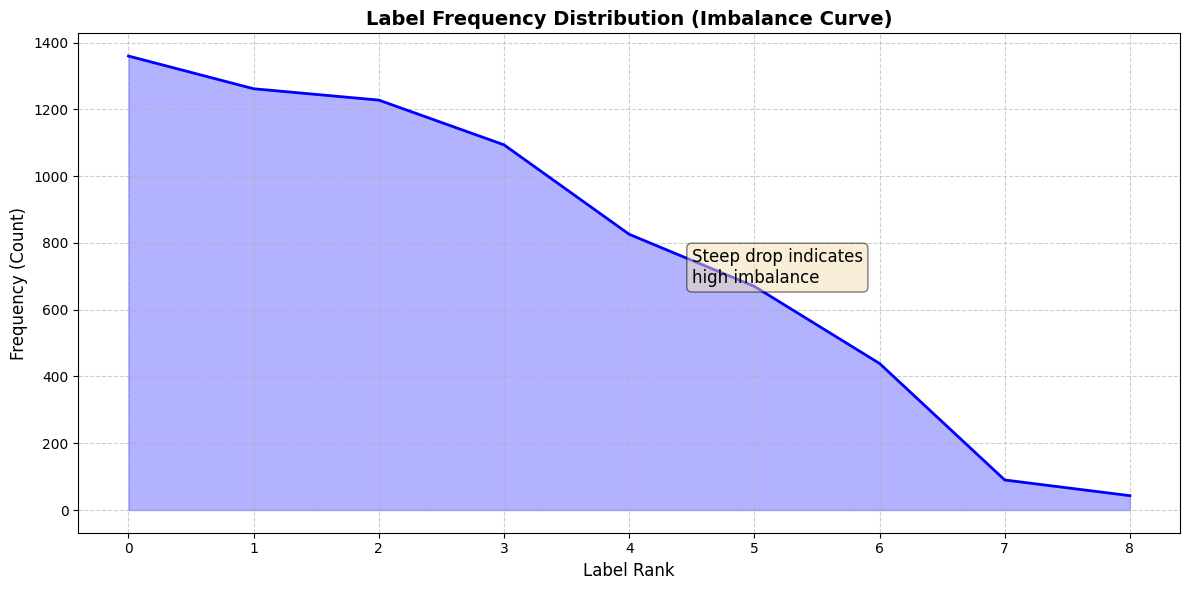

C:\Users\eggoni\AppData\Local\Temp\ipykernel_25964\3553405979.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bottom_20.values, y=bottom_20.index, palette='rocket')


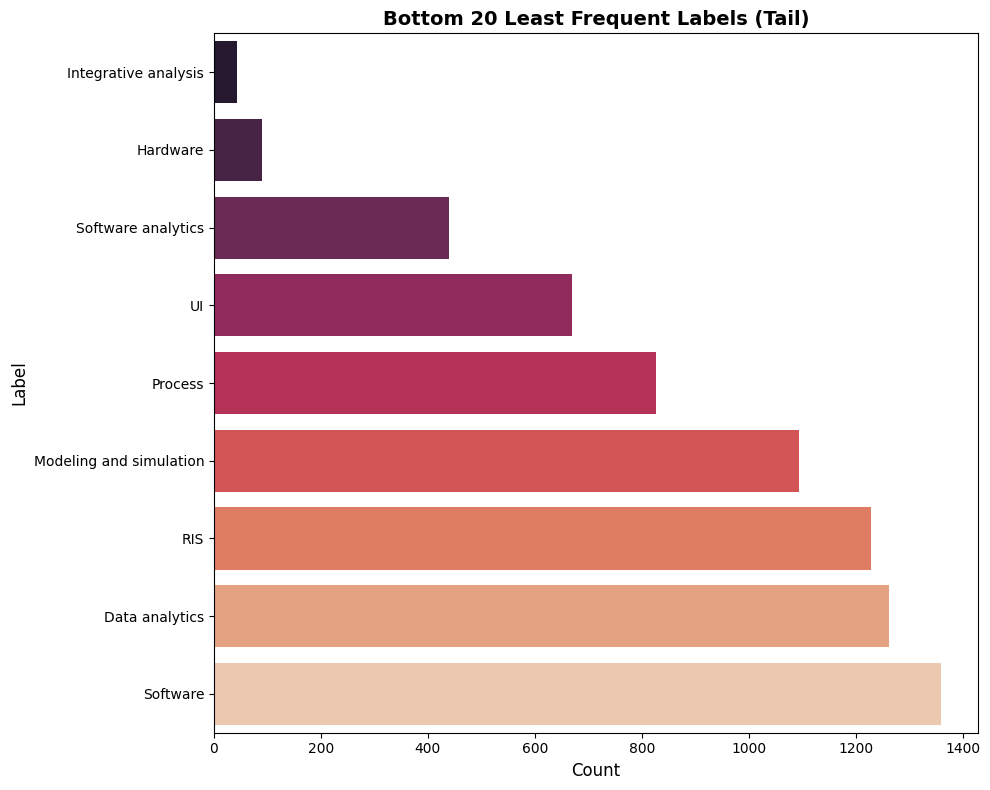

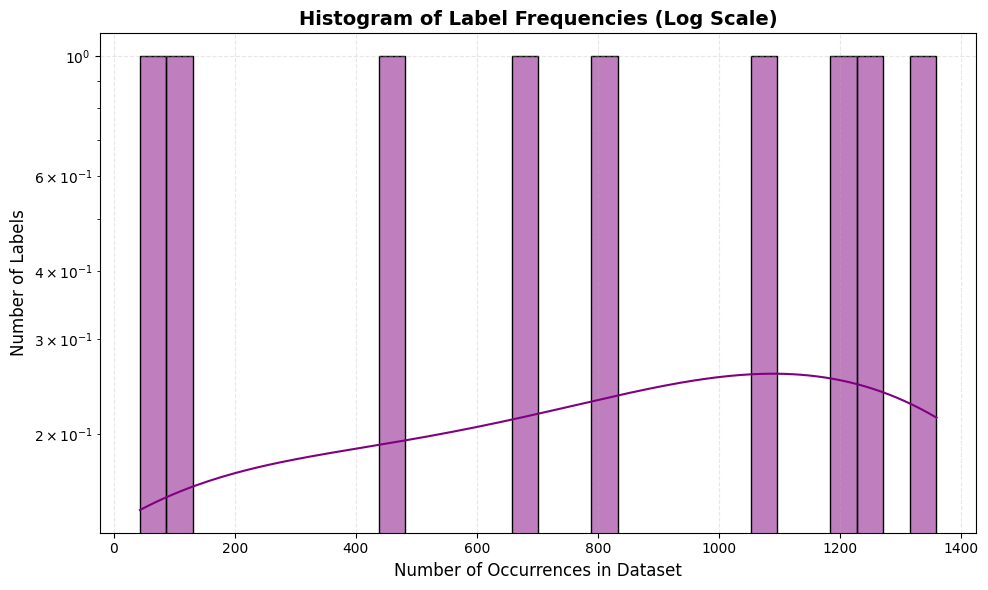

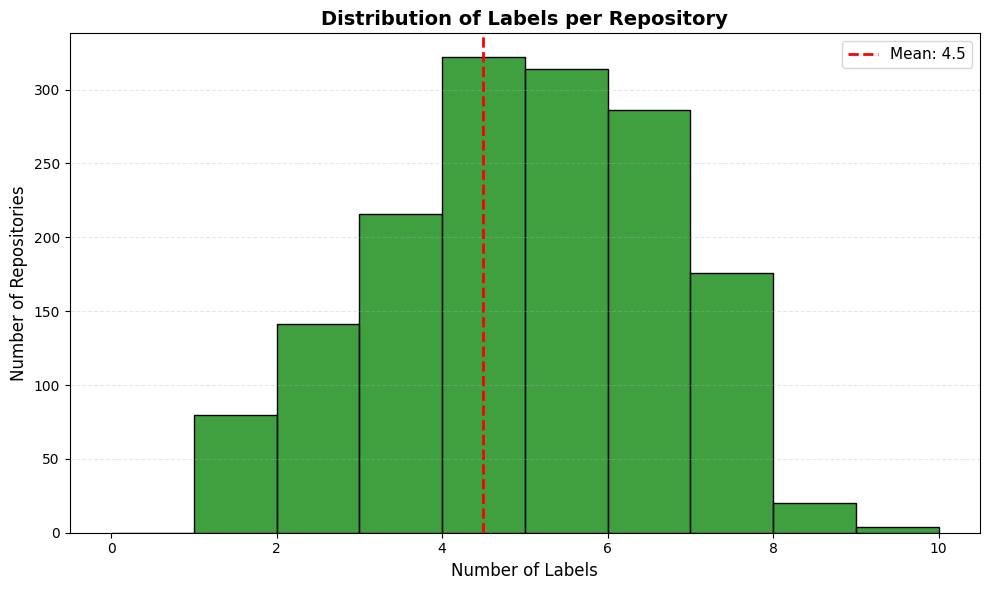

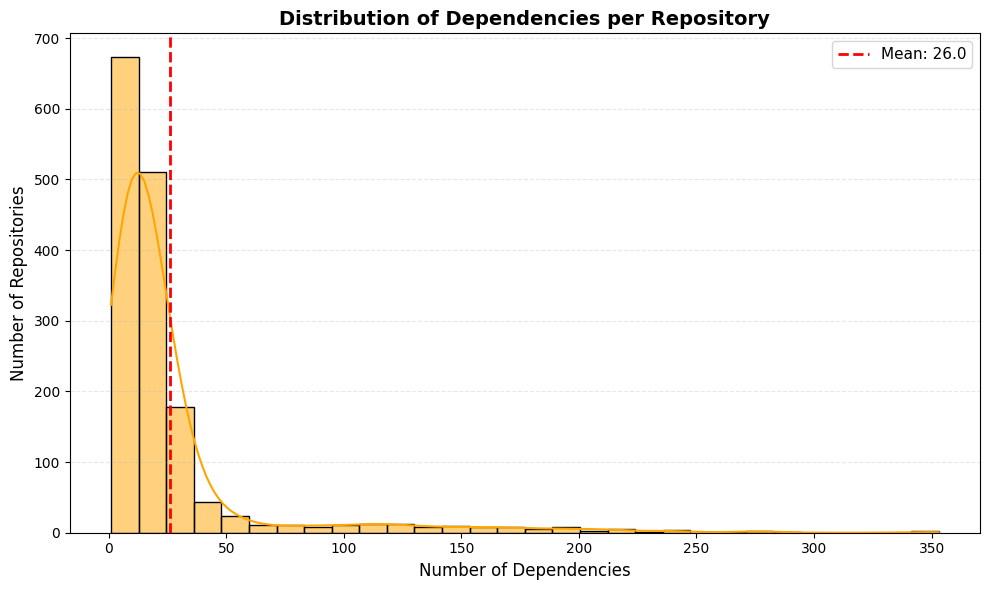

In [8]:
# 3.5 Data Visualization and Imbalance Analysis
if not df.empty:
    print("Visualizing data distributions and Class Imbalance...")
    
    # Flatten lists to count occurrences (Global Stats)
    all_labels = [label for sublist in df['filtered_labels'] for label in sublist]
    all_deps = [dep for sublist in df['filtered_deps'] for dep in sublist]
    
    # Per-Repository Counts (Row-wise Stats)
    labels_per_repo = df['filtered_labels'].apply(len)
    deps_per_repo = df['filtered_deps'].apply(len)
    
    label_counts = pd.Series(all_labels).value_counts()
    dep_counts = pd.Series(all_deps).value_counts()
    
    n_unique_labels = len(label_counts)
    
    # --- Text Statistics ---
    print(f"\n{'='*40}")
    print(f"--- Label Statistics (Global) ---")
    print(f"Total Unique Labels: {n_unique_labels}")
    print(f"Most Frequent Label: '{label_counts.index[0]}' ({label_counts.iloc[0]} occurrences)")
    print(f"Least Frequent Label: '{label_counts.index[-1]}' ({label_counts.iloc[-1]} occurrences)")
    
    print(f"\n--- Per-Repository Statistics (Cardinality) ---")
    print(f"Avg Labels per Repo: {labels_per_repo.mean():.2f} (Median: {labels_per_repo.median()})")
    print(f"Max Labels in a Repo: {labels_per_repo.max()}")
    print(f"Avg Dependencies per Repo: {deps_per_repo.mean():.2f} (Median: {deps_per_repo.median()})")
    print(f"Max Dependencies in a Repo: {deps_per_repo.max()}")
    
    # Identify Imbalance
    print("\n--- Class Imbalance Insights ---")
    print(f"Top 5 Labels account for {label_counts.head(5).sum() / label_counts.sum() * 100:.2f}% of all label assignments.")
    if n_unique_labels > 1:
        print(f"Bottom 50% of labels account for {label_counts.tail(int(n_unique_labels/2)).sum() / label_counts.sum() * 100:.2f}% of all label assignments.")
    print(f"{'='*40}\n")

    # --- Individual Visualizations ---
    
    # 1. Top 20 Labels
    plt.figure(figsize=(10, 8))
    sns.barplot(x=label_counts.head(20).values, y=label_counts.head(20).index, palette='viridis')
    plt.title(f'Top 20 Most Frequent Labels (Head)', fontsize=14, fontweight='bold')
    plt.xlabel('Count', fontsize=12)
    plt.ylabel('Label', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # 2. Label Frequency Distribution (Long Tail)
    plt.figure(figsize=(12, 6))
    plt.plot(range(len(label_counts)), label_counts.values, color='blue', linewidth=2)
    plt.fill_between(range(len(label_counts)), label_counts.values, color='blue', alpha=0.3)
    plt.title('Label Frequency Distribution (Imbalance Curve)', fontsize=14, fontweight='bold')
    plt.xlabel('Label Rank', fontsize=12)
    plt.ylabel('Frequency (Count)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.text(len(label_counts)*0.5, label_counts.max()*0.5, 'Steep drop indicates\nhigh imbalance', 
             fontsize=12, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    plt.tight_layout()
    plt.show()

    # 3. Bottom 20 Labels (Rare Classes)
    plt.figure(figsize=(10, 8))
    bottom_20 = label_counts.tail(20).sort_values(ascending=True) 
    sns.barplot(x=bottom_20.values, y=bottom_20.index, palette='rocket')
    plt.title('Bottom 20 Least Frequent Labels (Tail)', fontsize=14, fontweight='bold')
    plt.xlabel('Count', fontsize=12)
    plt.ylabel('Label', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # 4. Histogram of Label Counts (How many labels have X samples?)
    plt.figure(figsize=(10, 6))
    sns.histplot(label_counts, bins=30, kde=True, color='purple')
    plt.title('Histogram of Label Frequencies (Log Scale)', fontsize=14, fontweight='bold')
    plt.xlabel('Number of Occurrences in Dataset', fontsize=12)
    plt.ylabel('Number of Labels', fontsize=12)
    plt.yscale('log')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # 5. Distribution of Labels per Repository (Multi-label Cardinality)
    plt.figure(figsize=(10, 6))
    sns.histplot(labels_per_repo, bins=range(0, labels_per_repo.max() + 2), kde=False, color='green')
    plt.title('Distribution of Labels per Repository', fontsize=14, fontweight='bold')
    plt.xlabel('Number of Labels', fontsize=12)
    plt.ylabel('Number of Repositories', fontsize=12)
    plt.axvline(labels_per_repo.mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {labels_per_repo.mean():.1f}')
    plt.legend(fontsize=11)
    plt.grid(True, axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 6. Distribution of Dependencies per Repository
    plt.figure(figsize=(10, 6))
    sns.histplot(deps_per_repo, bins=30, kde=True, color='orange')
    plt.title('Distribution of Dependencies per Repository', fontsize=14, fontweight='bold')
    plt.xlabel('Number of Dependencies', fontsize=12)
    plt.ylabel('Number of Repositories', fontsize=12)
    plt.axvline(deps_per_repo.mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {deps_per_repo.mean():.1f}')
    plt.legend(fontsize=11)
    plt.grid(True, axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
# JOSS ID-based Train/Test Split for unbiased LLM vs ML comparison
# Uses the same JOSS IDs evaluated by the LLM as the holdout test set

import os

LLM_RESULTS_FILE = 'llm_results.csv'  # Update path if needed

def split_by_joss_ids(X, y, df, test_joss_ids):
    """Split X/y using JOSS IDs so ML and LLM are evaluated on identical samples."""
    id_col = None
    for col in ['joss_id', 'id', 'paper_id', 'ID']:
        if col in df.columns:
            id_col = col
            break
    
    if id_col is None:
        print("⚠️ No JOSS ID column found. Will use random split instead.")
        return None, None, None, None, None, None
    
    df_reset = df.reset_index(drop=True)
    test_joss_set = set(int(x) for x in test_joss_ids)
    test_mask = df_reset[id_col].astype(int).isin(test_joss_set)
    
    matched = test_mask.sum()
    print(f"✅ Matched {matched}/{len(test_joss_ids)} LLM JOSS IDs in main dataset")
    
    if matched == 0:
        print("⚠️ No JOSS IDs matched. Will use random split instead.")
        return None, None, None, None, None, None
    
    train_idx = df_reset.index[~test_mask].tolist()
    test_idx  = df_reset.index[test_mask].tolist()
    
    # Retrieve matched JOSS IDs for reference
    matched_ids = df_reset.loc[test_idx, id_col].tolist()
    
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx], train_idx, matched_ids

if not df.empty:
    # Try JOSS ID-based split
    if os.path.exists(LLM_RESULTS_FILE):
        llm_df = pd.read_csv(LLM_RESULTS_FILE)
        test_joss_ids = llm_df['joss_id'].dropna().astype(int).tolist()
        print(f"Loaded {len(test_joss_ids)} JOSS IDs from LLM results file")
        
        X_train, X_test, y_train, y_test, train_idx, matched_ids = split_by_joss_ids(
            X, y, df.reset_index(drop=True), test_joss_ids
        )
        
        if X_train is not None:
            split_method = "JOSS ID-based (matched to LLM evaluation set)"
        else:
            # Fallback to random
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)
            split_method = "Random 70/30 (JOSS ID match failed)"
    else:
        print(f"⚠️ LLM results file '{LLM_RESULTS_FILE}' not found. Using random split.")
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)
        split_method = "Random 70/30"
    
    print(f"\n{'='*50}")
    print(f"Split Method : {split_method}")
    print(f"Train Samples: {X_train.shape[0]}")
    print(f"Test Samples : {X_test.shape[0]}")
    print(f"Test %       : {X_test.shape[0] / X.shape[0] * 100:.1f}%")
    print(f"{'='*50}")
    print("\n✅ Test set is now the SAME papers evaluated by the LLM.")
    print("   ML predictions on X_test can be directly compared to LLM predictions.")

In [20]:
# 4. Train/Test Split and Model Training
if not df.empty:
    print("Splitting data...")
    # Note: Standard train_test_split is random. For rigorous multi-label evaluation, 
    # 'iterative_train_test_split' from scikit-multilearn is recommended to maintain label distribution,
    # but standard split is acceptable for initial benchmarking.
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

    # Define models to test
    # CRITICAL UPDATE: Added class_weight='balanced' to handle the high class imbalance identified in EDA.
    models = {
        "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
        "Logistic Regression": OneVsRestClassifier(LogisticRegression(solver='liblinear', class_weight='balanced', random_state=42)),
        "Linear SVC": OneVsRestClassifier(LinearSVC(class_weight='balanced', random_state=42, dual=False)), # dual=False for n_samples > n_features
        "MLP Classifier": MLPClassifier(random_state=42, max_iter=500) # MLP doesn't support class_weight directly
    }

    results = []

    for name, clf in models.items():
        print(f"\n{'='*20}")
        print(f"Training {name}...")
        clf.fit(X_train, y_train)

        # 5. Evaluation
        print(f"Evaluating {name}...")
        y_pred = clf.predict(X_test)

        # Calculate metrics
        # Accuracy in multi-label is "Exact Match Ratio" (harsh metric)
        acc = accuracy_score(y_test, y_pred)
        # F1 Micro is best for imbalanced multi-label datasets
        f1_micro = f1_score(y_test, y_pred, average='micro')
        # F1 Macro treats all classes equally (good for checking performance on rare classes)
        f1_macro = f1_score(y_test, y_pred, average='macro')
        # Hamming Loss is the fraction of wrong labels to total labels
        hl = hamming_loss(y_test, y_pred)

        results.append({
            "Model": name,
            "Accuracy": acc,
            "F1 Micro": f1_micro,
            "F1 Macro": f1_macro,
            "Hamming Loss": hl
        })

        print(f"\nClassification Report for {name}:")
        # zero_division=0 handles warnings for classes with no predicted samples
        print(classification_report(y_test, y_pred, target_names=mlb_y.classes_, zero_division=0))

Splitting data...

Training Random Forest...
Evaluating Random Forest...

Classification Report for Random Forest:
                         precision    recall  f1-score   support

         Data analytics       0.98      0.93      0.95       382
               Hardware       1.00      0.48      0.65        27
   Integrative analysis       1.00      0.15      0.27        13
Modeling and simulation       0.97      0.83      0.90       333
                Process       0.98      0.77      0.86       247
                    RIS       0.95      0.90      0.92       355
               Software       0.96      0.89      0.92       408
     Software analytics       0.95      0.53      0.68       108
                     UI       0.97      0.50      0.66       201

              micro avg       0.97      0.81      0.88      2074
              macro avg       0.97      0.66      0.76      2074
           weighted avg       0.97      0.81      0.87      2074
            samples avg       0.93    

C:\Users\eggoni\AppData\Roaming\Python\Python313\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\eggoni\AppData\Roaming\Python\Python313\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Evaluating Linear SVC...

Classification Report for Linear SVC:
                         precision    recall  f1-score   support

         Data analytics       1.00      0.92      0.96       382
               Hardware       0.95      0.70      0.81        27
   Integrative analysis       1.00      0.31      0.47        13
Modeling and simulation       0.97      0.92      0.94       333
                Process       0.98      0.92      0.95       247
                    RIS       0.97      0.90      0.93       355
               Software       0.98      0.91      0.94       408
     Software analytics       0.96      0.86      0.91       108
                     UI       0.98      0.88      0.92       201

              micro avg       0.98      0.90      0.94      2074
              macro avg       0.98      0.81      0.87      2074
           weighted avg       0.98      0.90      0.94      2074
            samples avg       0.95      0.87      0.90      2074


Training MLP Classifie

In [23]:
# 5. Training with Cross-Validation and Class Balancing
from sklearn.model_selection import cross_validate, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, hamming_loss
import numpy as np
import pandas as pd

if not df.empty:
    print("Splitting data...")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

    # Define models with class balancing where possible
    models = {
        "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
        "Logistic Regression": OneVsRestClassifier(LogisticRegression(solver='liblinear', class_weight='balanced', random_state=42, max_iter=1000)),
        "Linear SVC": OneVsRestClassifier(LinearSVC(class_weight='balanced', random_state=42, dual='auto', max_iter=2000)),
        "MLP Classifier": MLPClassifier(random_state=42, max_iter=500, early_stopping=True)
    }

    results = []
    cv_results_list = []

    print(f"Training on {X_train.shape[0]} samples, Testing on {X_test.shape[0]} samples.")

    for name, clf in models.items():
        print(f"\n{'='*30}")
        print(f"Processing {name}...")
        
        # 1. Cross-Validation on Training Set
        print(f"  Running 5-Fold Cross-Validation...")
        scoring = ['f1_micro', 'f1_macro', 'accuracy']
        cv_scores = cross_validate(clf, X_train, y_train, cv=5, scoring=scoring, return_train_score=False)
        
        mean_cv_f1_micro = np.mean(cv_scores['test_f1_micro'])
        std_cv_f1_micro = np.std(cv_scores['test_f1_micro'])
        
        print(f"  CV F1 Micro: {mean_cv_f1_micro:.4f} (+/- {std_cv_f1_micro:.4f})")
        
        # 2. Train on Full Training Set
        print(f"  Training on full training set...")
        clf.fit(X_train, y_train)

        # 3. Evaluate on Held-out Test Set
        print(f"  Evaluating on Test Set...")
        y_pred = clf.predict(X_test)

        # Calculate metrics
        acc = accuracy_score(y_test, y_pred)
        f1_micro = f1_score(y_test, y_pred, average='micro')
        f1_macro = f1_score(y_test, y_pred, average='macro')
        hl = hamming_loss(y_test, y_pred)

        results.append({
            "Model": name,
            "Test Accuracy": acc,
            "Test F1 Micro": f1_micro,
            "Test F1 Macro": f1_macro,
            "Test Hamming Loss": hl,
            "CV F1 Micro (Mean)": mean_cv_f1_micro
        })

        print(f"\n  Test Classification Report for {name}:")
        print(classification_report(y_test, y_pred, target_names=mlb_y.classes_, zero_division=0))

    # 6. Comparison
    print(f"\n{'='*30}")
    print("Final Model Comparison:")
    results_df = pd.DataFrame(results)
    # Sort by Test F1 Micro
    display_cols = ["Model", "CV F1 Micro (Mean)", "Test F1 Micro", "Test F1 Macro", "Test Accuracy", "Test Hamming Loss"]
    print(results_df[display_cols].sort_values(by="Test F1 Micro", ascending=False))

Splitting data...
Training on 1091 samples, Testing on 468 samples.

Processing Random Forest...
  Running 5-Fold Cross-Validation...
  CV F1 Micro: 0.8728 (+/- 0.0053)
  Training on full training set...
  Evaluating on Test Set...

  Test Classification Report for Random Forest:
                         precision    recall  f1-score   support

         Data analytics       0.98      0.93      0.95       382
               Hardware       1.00      0.48      0.65        27
   Integrative analysis       1.00      0.15      0.27        13
Modeling and simulation       0.97      0.83      0.90       333
                Process       0.98      0.77      0.86       247
                    RIS       0.95      0.90      0.92       355
               Software       0.96      0.89      0.92       408
     Software analytics       0.95      0.53      0.68       108
                     UI       0.97      0.50      0.66       201

              micro avg       0.97      0.81      0.88      2074
  

Visualizing Model Performance...


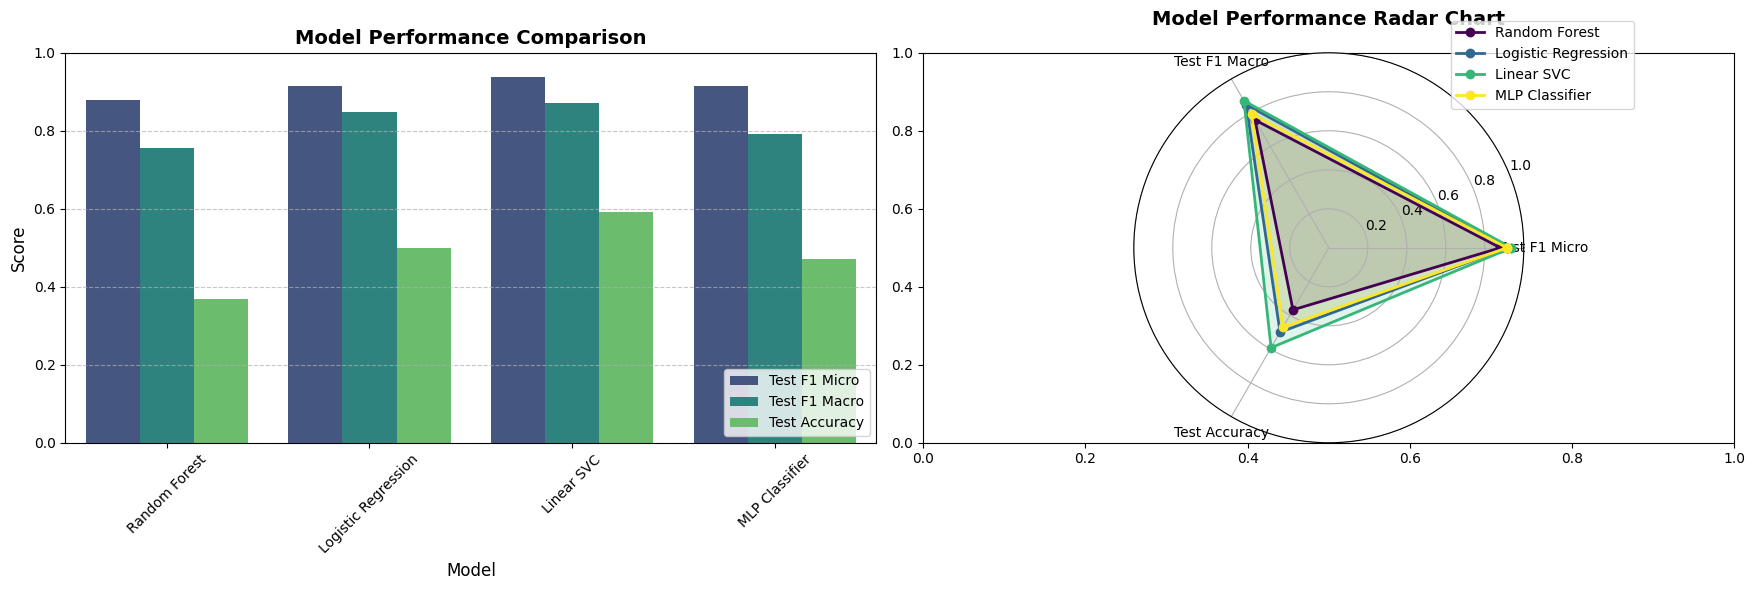


****************************************
🏆 BEST MODEL: Linear SVC
   Test F1 Micro: 0.9367
****************************************

Detailed Stats for Linear SVC:
Model                 Linear SVC
Test Accuracy            0.59188
Test F1 Micro           0.936715
Test F1 Macro           0.870213
Test Hamming Loss       0.059829
CV F1 Micro (Mean)      0.930895


In [24]:
# 7. Visualize Model Comparison
if not results_df.empty:
    print("Visualizing Model Performance...")
    
    # Melt DataFrame for easier plotting with seaborn
    results_melted = results_df.melt(id_vars="Model", 
                                     value_vars=["Test F1 Micro", "Test F1 Macro", "Test Accuracy"],
                                     var_name="Metric", value_name="Score")
    
    # Create figure with two subplots
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # Plot 1: Bar chart comparison
    sns.barplot(data=results_melted, x="Model", y="Score", hue="Metric", palette="viridis", ax=axes[0])
    axes[0].set_title("Model Performance Comparison", fontsize=14, fontweight='bold')
    axes[0].set_ylim(0, 1.0)
    axes[0].set_ylabel("Score", fontsize=12)
    axes[0].set_xlabel("Model", fontsize=12)
    axes[0].legend(loc='lower right')
    axes[0].grid(axis='y', linestyle='--', alpha=0.7)
    axes[0].tick_params(axis='x', rotation=45)
    
    # Plot 2: Radar chart for comprehensive view
    from math import pi
    
    # Prepare data for radar chart (normalize metrics to 0-1 scale)
    metrics_for_radar = ["Test F1 Micro", "Test F1 Macro", "Test Accuracy"]
    num_vars = len(metrics_for_radar)
    angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
    angles += angles[:1]  # Complete the circle
    
    ax = axes[1]
    ax = plt.subplot(122, polar=True)
    
    # Plot each model
    colors = plt.cm.viridis(np.linspace(0, 1, len(results_df)))
    for idx, row in results_df.iterrows():
        values = row[metrics_for_radar].values.tolist()
        values += values[:1]  # Complete the circle
        ax.plot(angles, values, 'o-', linewidth=2, label=row['Model'], color=colors[idx])
        ax.fill(angles, values, alpha=0.15, color=colors[idx])
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics_for_radar, size=10)
    ax.set_ylim(0, 1)
    ax.set_title("Model Performance Radar Chart", fontsize=14, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    ax.grid(True)
    
    plt.tight_layout()
    plt.show()

    # Highlight Best Model
    best_model_row = results_df.loc[results_df['Test F1 Micro'].idxmax()]
    best_model_name = best_model_row['Model']
    best_f1_micro = best_model_row['Test F1 Micro']
    
    print(f"\n{'*'*40}")
    print(f"🏆 BEST MODEL: {best_model_name}")
    print(f"   Test F1 Micro: {best_f1_micro:.4f}")
    print(f"{'*'*40}\n")
    
    # Display detailed stats for best model
    print(f"Detailed Stats for {best_model_name}:")
    print(best_model_row.to_string())
    
    # Compare Ensemble vs Individual Models
    if "Ensemble (RF + SVC)" in results_df['Model'].values:
        print(f"\n{'='*50}")
        print("Ensemble vs Individual Component Analysis:")
        print(f"{'='*50}")
        ensemble_row = results_df[results_df['Model'] == "Ensemble (RF + SVC)"].iloc[0]
        rf_row = results_df[results_df['Model'] == "Random Forest"].iloc[0]
        svc_row = results_df[results_df['Model'] == "Linear SVC"].iloc[0]
        
        print(f"\nRandom Forest      F1-Micro: {rf_row['Test F1 Micro']:.4f}")
        print(f"Linear SVC         F1-Micro: {svc_row['Test F1 Micro']:.4f}")
        print(f"Ensemble (RF+SVC)  F1-Micro: {ensemble_row['Test F1 Micro']:.4f}")
        
        improvement_vs_rf = ((ensemble_row['Test F1 Micro'] - rf_row['Test F1 Micro']) / rf_row['Test F1 Micro'] * 100)
        improvement_vs_svc = ((ensemble_row['Test F1 Micro'] - svc_row['Test F1 Micro']) / svc_row['Test F1 Micro'] * 100)
        
        print(f"\nEnsemble improvement over Random Forest: {improvement_vs_rf:+.2f}%")
        print(f"Ensemble improvement over Linear SVC:    {improvement_vs_svc:+.2f}%")

Visualizing Model Performance...


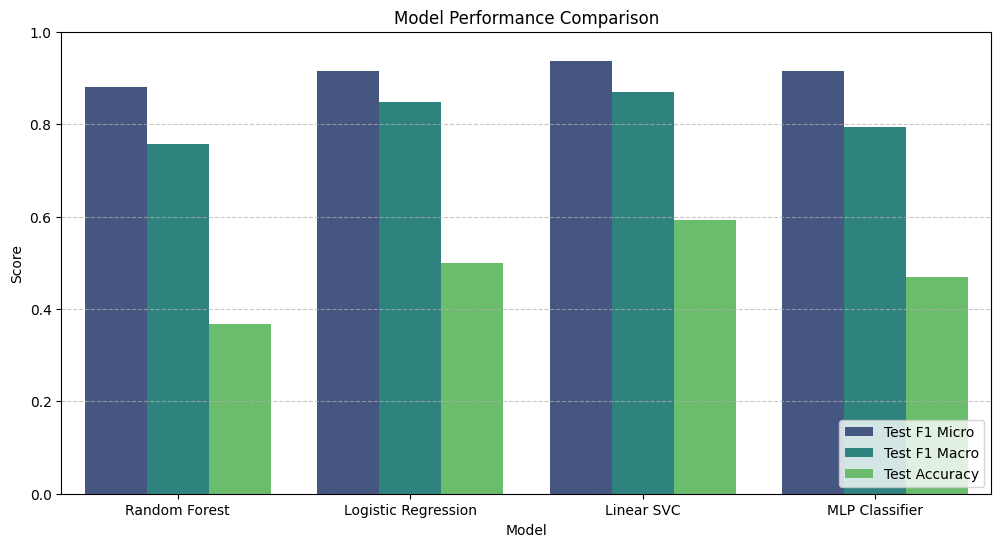


****************************************
🏆 BEST MODEL: Linear SVC
   Test F1 Micro: 0.9367
****************************************

Detailed Stats for Linear SVC:
Model                 Linear SVC
Test Accuracy            0.59188
Test F1 Micro           0.936715
Test F1 Macro           0.870213
Test Hamming Loss       0.059829
CV F1 Micro (Mean)      0.930895


In [25]:
# 7. Visualize Model Comparison
if not results_df.empty:
    print("Visualizing Model Performance...")
    
    # Melt DataFrame for easier plotting with seaborn
    results_melted = results_df.melt(id_vars="Model", 
                                     value_vars=["Test F1 Micro", "Test F1 Macro", "Test Accuracy"],
                                     var_name="Metric", value_name="Score")
    
    plt.figure(figsize=(12, 6))
    sns.barplot(data=results_melted, x="Model", y="Score", hue="Metric", palette="viridis")
    plt.title("Model Performance Comparison")
    plt.ylim(0, 1.0)
    plt.ylabel("Score")
    plt.xlabel("Model")
    plt.legend(loc='lower right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # Highlight Best Model
    best_model_row = results_df.loc[results_df['Test F1 Micro'].idxmax()]
    best_model_name = best_model_row['Model']
    best_f1_micro = best_model_row['Test F1 Micro']
    
    print(f"\n{'*'*40}")
    print(f"🏆 BEST MODEL: {best_model_name}")
    print(f"   Test F1 Micro: {best_f1_micro:.4f}")
    print(f"{'*'*40}\n")
    
    # Display detailed stats for best model
    print(f"Detailed Stats for {best_model_name}:")
    print(best_model_row.to_string())

In [26]:
# 8. Save the Best Model
import joblib
import os

if not results_df.empty:
    # Identify best model instance
    best_model_name = results_df.loc[results_df['Test F1 Micro'].idxmax()]['Model']
    best_clf = models[best_model_name] # Retrieve the actual trained model object
    
    # Create a dictionary to store all necessary components
    model_bundle = {
        'model': best_clf,
        'mlb_X': mlb_X, # Binarizer for dependencies
        'mlb_y': mlb_y, # Binarizer for labels
        'valid_dependencies': valid_dependencies_lower, # Set of valid dependencies
        'model_name': best_model_name
    }
    
    # Save to file
    save_path = 'best_multilabel_model.joblib'
    joblib.dump(model_bundle, save_path)
    
    print(f"✅ Successfully saved '{best_model_name}' and preprocessors to '{save_path}'")
    print(f"File size: {os.path.getsize(save_path) / 1024 / 1024:.2f} MB")

✅ Successfully saved 'Linear SVC' and preprocessors to 'best_multilabel_model.joblib'
File size: 0.68 MB


In [29]:
# 9. Load and Use the Saved Model (Inference Example)
import joblib

def predict_labels(dependencies, model_path='best_multilabel_model.joblib'):
    """
    Predicts labels for a given list of dependencies using the saved model.
    """
    print(f"Loading model from {model_path}...")
    try:
        bundle = joblib.load(model_path)
        clf = bundle['model']
        mlb_X = bundle['mlb_X']
        mlb_y = bundle['mlb_y']
        valid_deps = bundle['valid_dependencies']
    except FileNotFoundError:
        print("Error: Model file not found. Please train and save the model first.")
        return []

    # Preprocess input
    # 1. Normalize and filter dependencies
    filtered_deps = [d.lower() for d in dependencies if d.lower() in valid_deps]
    
    if not filtered_deps:
        print("Warning: No valid dependencies found in input.")
        return []
    
    # 2. Transform to feature vector
    # mlb.transform expects a list of lists (iterable of iterables)
    X_input = mlb_X.transform([filtered_deps])
    
    # 3. Predict
    y_pred_bin = clf.predict(X_input)
    
    # 4. Inverse transform to get label names
    predicted_labels = mlb_y.inverse_transform(y_pred_bin)
    
    return predicted_labels[0] # Return the tuple of labels for the first (and only) input

# --- Test the Inference Function ---
# Example: A list of dependencies that might imply 'Data Analytics' or 'Modeling'
test_deps = ['pandas', 'numpy', 'scikit-learn', 'matplotlib']

print(f"\nInput Dependencies: {test_deps}")
predicted = predict_labels(test_deps)
print(f"Predicted Labels: {predicted}")


Input Dependencies: ['pandas', 'numpy', 'scikit-learn', 'matplotlib']
Loading model from best_multilabel_model.joblib...
Predicted Labels: ('Data analytics', 'Modeling and simulation')


In [30]:
# 10. Compare Actual vs Predicted on Test Set and Save Results
if 'best_clf' in locals() and 'best_model_name' in locals():
    print(f"Comparing predictions using best model: {best_model_name}")

    # Predict on the full test set
    y_test_pred = best_clf.predict(X_test)

    # Convert binary labels back to strings
    actual_labels = mlb_y.inverse_transform(y_test)
    predicted_labels = mlb_y.inverse_transform(y_test_pred)

    # Create a comparison DataFrame
    comparison_df = pd.DataFrame({
        'Actual Labels': actual_labels,
        'Predicted Labels': predicted_labels
    })

    # Add a column to check for exact matches
    comparison_df['Exact Match'] = comparison_df['Actual Labels'] == comparison_df['Predicted Labels']

    # Save to CSV
    output_csv = 'test_set_predictions.csv'
    comparison_df.to_csv(output_csv, index=False)
    print(f"✅ Saved test set predictions to '{output_csv}'")

    # Display a sample of results
    print("\nSample of Test Predictions (First 20):")
    # Set pandas display options to show full column width for lists
    pd.set_option('display.max_colwidth', None)
    print(comparison_df.head(20))

    # Show some statistics about the predictions
    print("\nPrediction Statistics:")
    print(f"Total Test Samples: {len(comparison_df)}")
    print(f"Exact Matches: {comparison_df['Exact Match'].sum()}")
    print(f"Exact Match Percentage: {comparison_df['Exact Match'].mean() * 100:.2f}%")

    # Show a few examples where the model made a mistake (if any)
    mistakes = comparison_df[~comparison_df['Exact Match']]
    if not mistakes.empty:
        print("\nSample of Mismatches (First 10):")
        print(mistakes.head(10))
else:
    print("⚠️ Error: Model not trained yet. Please run the training cells first.")

Comparing predictions using best model: Linear SVC
✅ Saved test set predictions to 'test_set_predictions.csv'

Sample of Test Predictions (First 20):
                                                                            Actual Labels  \
0                                                                                  (RIS,)   
1                                                                         (RIS, Software)   
2                   (Data analytics, Modeling and simulation, Process, RIS, Software, UI)   
3                            (Data analytics, Modeling and simulation, RIS, Software, UI)   
4                                            (Process, RIS, Software, Software analytics)   
5   (Data analytics, Modeling and simulation, Process, RIS, Software, Software analytics)   
6      (Data analytics, Integrative analysis, Modeling and simulation, RIS, Software, UI)   
7                        (Data analytics, Modeling and simulation, Process, Software, UI)   
8   (Data ana

Loading raw data for language & dependency EDA...


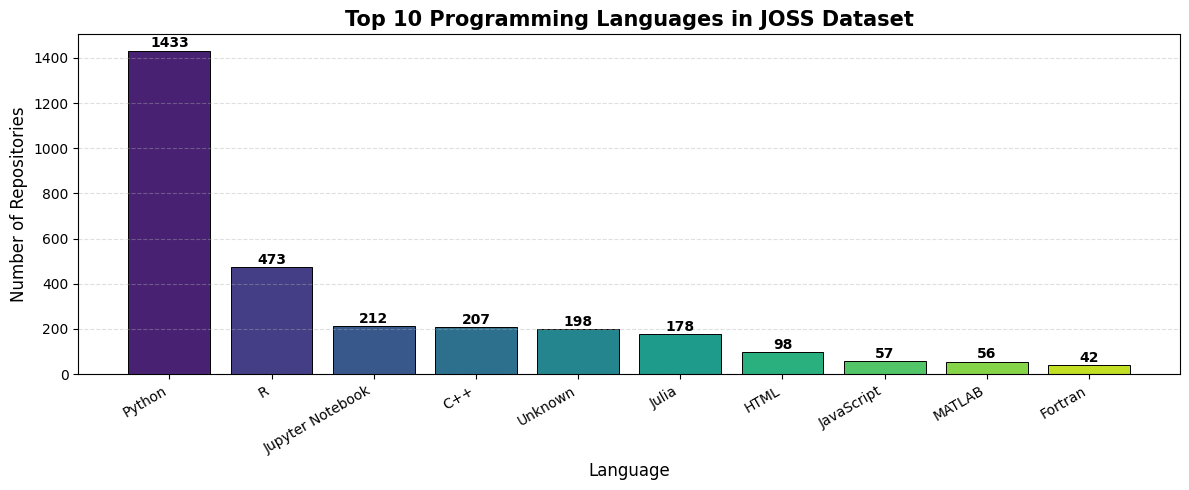


Language Distribution (Top 10):
Language
Python              1433
R                    473
Jupyter Notebook     212
C++                  207
Unknown              198
Julia                178
HTML                  98
JavaScript            57
MATLAB                56
Fortran               42


C:\Users\eggoni\AppData\Local\Temp\ipykernel_25220\1556686483.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=lang_dep_df, x='Language', y='dep_count', order=top5_langs,


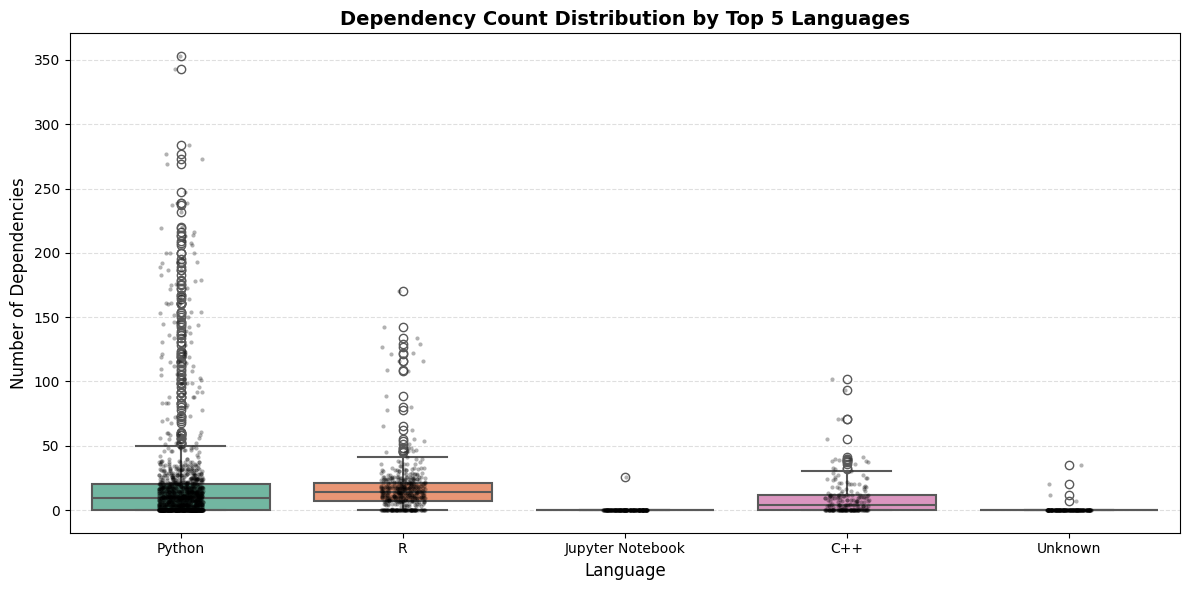


Dependency Count Statistics by Language:
                   count   mean    std  min  25%   50%   75%    max
Language                                                           
C++                207.0   9.31  14.98  0.0  0.0   4.0  12.0  102.0
Jupyter Notebook   212.0   0.12   1.79  0.0  0.0   0.0   0.0   26.0
Python            1433.0  21.10  41.87  0.0  0.0   9.0  20.0  353.0
R                  473.0  17.37  21.13  0.0  7.0  14.0  21.0  170.0
Unknown            198.0   0.37   3.01  0.0  0.0   0.0   0.0   35.0


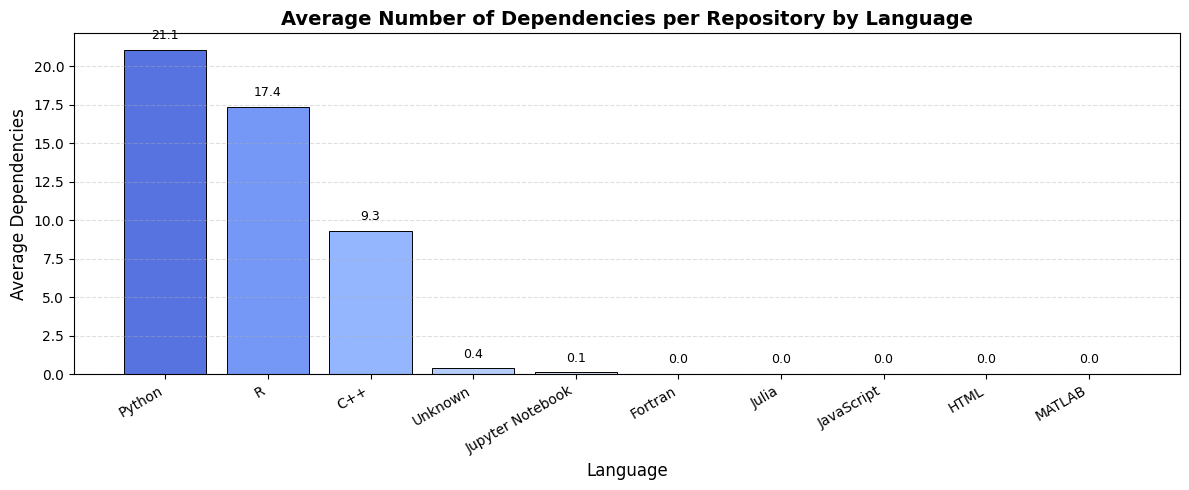

C:\Users\eggoni\AppData\Local\Temp\ipykernel_25220\1556686483.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dep_series.values, y=dep_series.index, palette='magma')


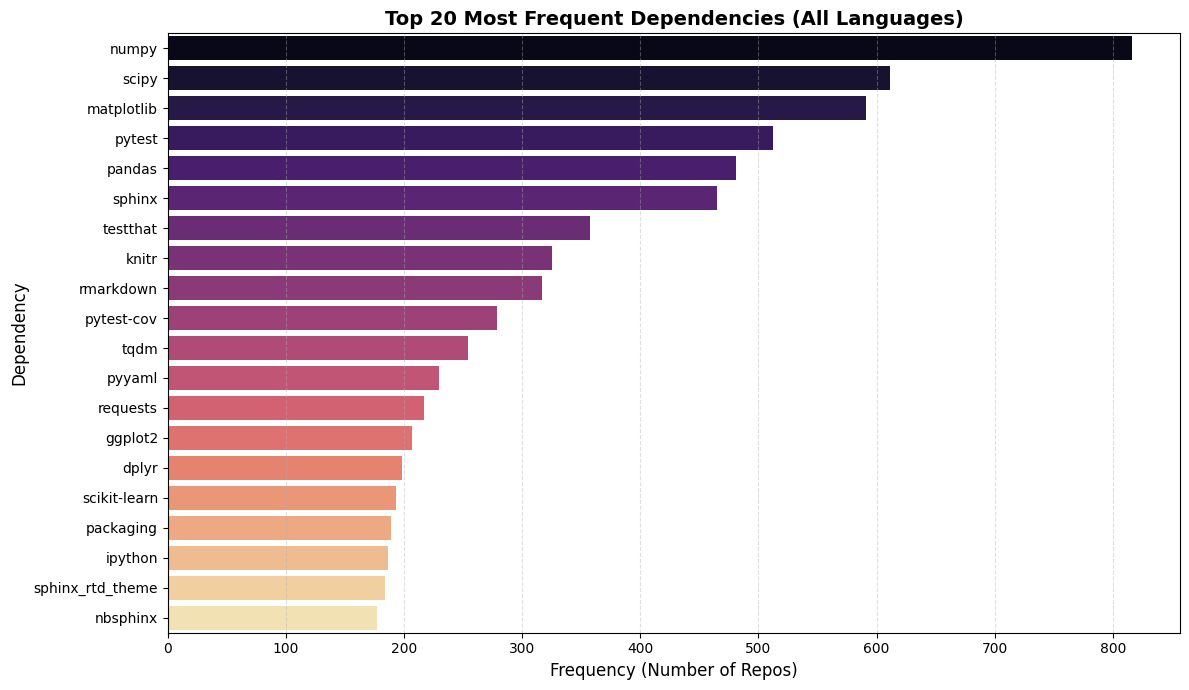


Building per-language dependency heatmap...


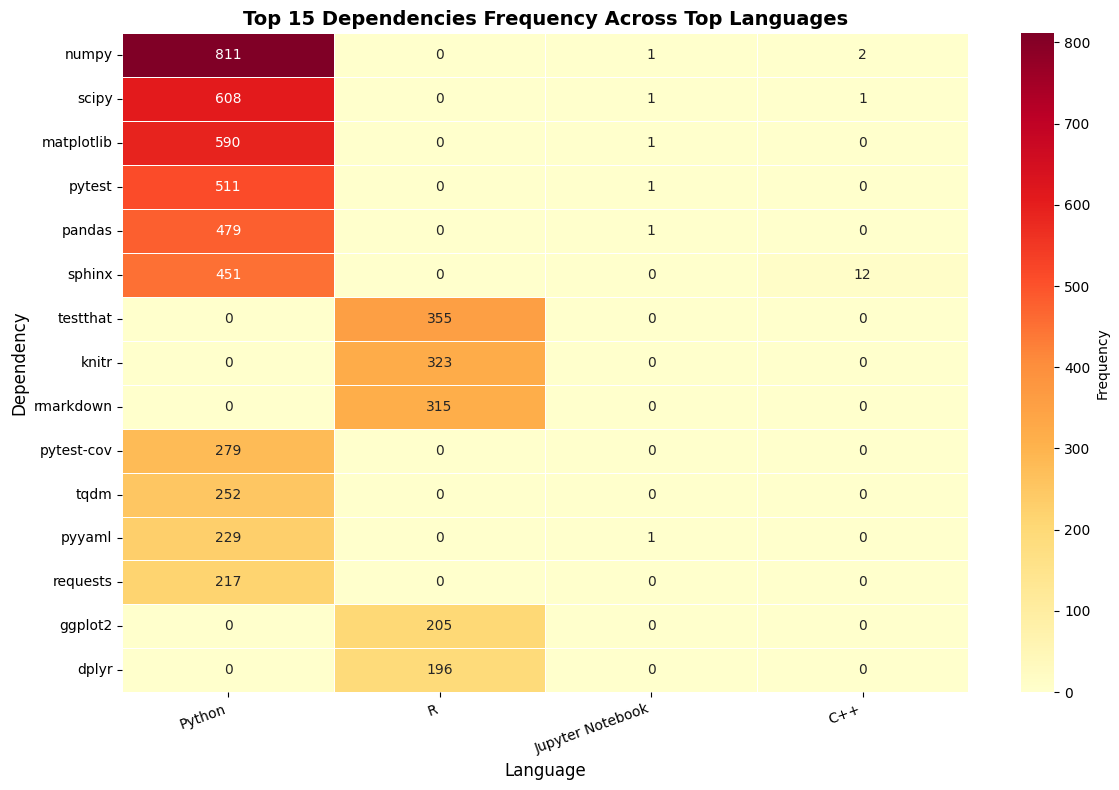

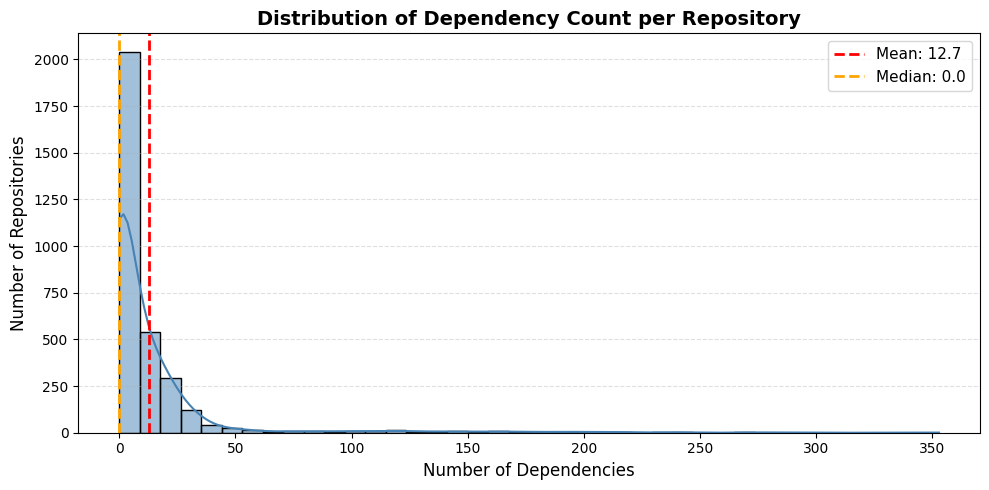


Overall Dependency Count Stats:
count    3199.00
mean       12.69
std        30.91
min         0.00
25%         0.00
50%         0.00
75%        14.00
max       353.00
Name: dep_count, dtype: float64


In [7]:
# EDA: Programming Language & Dependency Analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

print("Loading raw data for language & dependency EDA...")
raw_df = pd.read_csv('joss_all_with_dependency_labels1.csv')

# --- Parse dependency column ---
dep_col = 'dependecies_found' if 'dependecies_found' in raw_df.columns else 'dependencies_found'

def safe_parse(x):
    try:
        if isinstance(x, str) and x.strip().startswith('['):
            return ast.literal_eval(x)
        elif isinstance(x, str):
            return [i.strip() for i in x.split(',') if i.strip()]
        return []
    except:
        return []

raw_df['dep_list'] = raw_df[dep_col].apply(safe_parse)
raw_df['dep_count'] = raw_df['dep_list'].apply(len)
raw_df['Language'] = raw_df['Language'].fillna('Unknown')

lang_counts = raw_df['Language'].value_counts()
top_langs = lang_counts.head(10)
top5_langs = lang_counts.head(5).index.tolist()
all_deps_flat = [dep.lower().strip() for deps in raw_df['dep_list'] for dep in deps if dep.strip()]

# ============================================================
# 1. Language Distribution
# ============================================================
plt.figure(figsize=(12, 5))
colors = sns.color_palette('viridis', len(top_langs))
bars = plt.bar(top_langs.index, top_langs.values, color=colors, edgecolor='black', linewidth=0.7)
plt.title('Top 10 Programming Languages in JOSS Dataset', fontsize=15, fontweight='bold')
plt.xlabel('Language', fontsize=12)
plt.ylabel('Number of Repositories', fontsize=12)
plt.xticks(rotation=30, ha='right')
for bar, val in zip(bars, top_langs.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(val),
             ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print(f"\nLanguage Distribution (Top 10):")
print(top_langs.to_string())

# ============================================================
# 2. Dependency Count Distribution by Language
# ============================================================
lang_dep_df = raw_df[raw_df['Language'].isin(top5_langs)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=lang_dep_df, x='Language', y='dep_count', order=top5_langs,
            palette='Set2', linewidth=1.5)
sns.stripplot(data=lang_dep_df, x='Language', y='dep_count', order=top5_langs,
              color='black', alpha=0.3, size=3, jitter=True)
plt.title('Dependency Count Distribution by Top 5 Languages', fontsize=14, fontweight='bold')
plt.xlabel('Language', fontsize=12)
plt.ylabel('Number of Dependencies', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print("\nDependency Count Statistics by Language:")
print(lang_dep_df.groupby('Language')['dep_count'].describe().round(2))

# ============================================================
# 3. Average Dependencies per Language (bar chart)
# ============================================================
avg_deps = raw_df[raw_df['Language'].isin(top_langs.index)].groupby('Language')['dep_count'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
bars = plt.bar(avg_deps.index, avg_deps.values,
               color=sns.color_palette('coolwarm', len(avg_deps)), edgecolor='black', linewidth=0.7)
plt.title('Average Number of Dependencies per Repository by Language', fontsize=14, fontweight='bold')
plt.xlabel('Language', fontsize=12)
plt.ylabel('Average Dependencies', fontsize=12)
plt.xticks(rotation=30, ha='right')
for bar, val in zip(bars, avg_deps.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}',
             ha='center', va='bottom', fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# ============================================================
# 4. Top 20 Most Common Dependencies (Global)
# ============================================================
dep_series = pd.Series(all_deps_flat).value_counts().head(20)

plt.figure(figsize=(12, 7))
sns.barplot(x=dep_series.values, y=dep_series.index, palette='magma')
plt.title('Top 20 Most Frequent Dependencies (All Languages)', fontsize=14, fontweight='bold')
plt.xlabel('Frequency (Number of Repos)', fontsize=12)
plt.ylabel('Dependency', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# ============================================================
# 5. Top Dependencies per Language (heatmap)
# ============================================================
print("\nBuilding per-language dependency heatmap...")

top3_langs_for_heatmap = lang_counts.head(4).index.tolist()
top15_deps = [d for d, _ in pd.Series(all_deps_flat).value_counts().head(15).items()]

heatmap_data = {}
for lang in top3_langs_for_heatmap:
    lang_deps = raw_df[raw_df['Language'] == lang]['dep_list'].apply(
        lambda x: [d.lower().strip() for d in x]
    )
    dep_freq = pd.Series([d for deps in lang_deps for d in deps]).value_counts()
    heatmap_data[lang] = {dep: dep_freq.get(dep, 0) for dep in top15_deps}

heatmap_df = pd.DataFrame(heatmap_data).fillna(0)

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_df, cmap='YlOrRd', annot=True, fmt='.0f', linewidths=0.5,
            cbar_kws={'label': 'Frequency'})
plt.title('Top 15 Dependencies Frequency Across Top Languages', fontsize=14, fontweight='bold')
plt.xlabel('Language', fontsize=12)
plt.ylabel('Dependency', fontsize=12)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

# ============================================================
# 6. Dependency count histogram (all repos)
# ============================================================
plt.figure(figsize=(10, 5))
sns.histplot(raw_df['dep_count'], bins=40, kde=True, color='steelblue')
plt.axvline(raw_df['dep_count'].mean(), color='red', linestyle='--', linewidth=2,
            label=f"Mean: {raw_df['dep_count'].mean():.1f}")
plt.axvline(raw_df['dep_count'].median(), color='orange', linestyle='--', linewidth=2,
            label=f"Median: {raw_df['dep_count'].median():.1f}")
plt.title('Distribution of Dependency Count per Repository', fontsize=14, fontweight='bold')
plt.xlabel('Number of Dependencies', fontsize=12)
plt.ylabel('Number of Repositories', fontsize=12)
plt.legend(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print(f"\nOverall Dependency Count Stats:")
print(raw_df['dep_count'].describe().round(2))

In [ ]:
latex_text = r"""
\section{Exploratory Data Analysis}

\subsection{Dataset Overview}

The dataset used in this study is derived from the Journal of Open Source Software
(JOSS) repository and contains information about published software packages, their
primary programming languages, detected dependencies, and associated research-domain
labels.

\subsection{Programming Language Distribution}

Figure~\ref{fig:lang_dist} presents the distribution of primary programming languages
across all repositories in the JOSS dataset. Python dominates the corpus, accounting
for the largest share of repositories, followed by R and C++. The remaining languages,
including Julia, JavaScript, Fortran, and MATLAB, are comparatively rare. This
distribution reflects the broader trend in scientific computing, where Python and R
have become the de-facto standards for data-intensive research.

\begin{figure}[h]
    \centering
    \includegraphics[width=0.85\textwidth]{figures/fig1_language_distribution.png}
    \caption{Distribution of primary programming languages across JOSS repositories.
             Python and R collectively account for the majority of the corpus.}
    \label{fig:lang_dist}
\end{figure}

\subsection{Dependency Count Distribution by Language}

Figure~\ref{fig:dep_lang} illustrates the distribution of dependency counts per
repository, stratified by the top-5 programming languages. Python repositories exhibit
a notably higher median number of dependencies compared to C++ and R repositories.
The wide interquartile ranges and presence of high-count outliers suggest that
dependency usage is highly variable even within a single language ecosystem.

\begin{figure}[h]
    \centering
    \includegraphics[width=0.85\textwidth]{figures/fig2_dep_count_by_language.png}
    \caption{Box plots of dependency counts per repository for the five most frequent
             programming languages. Individual data points are overlaid as a strip plot.}
    \label{fig:dep_lang}
\end{figure}

\subsection{Average Dependency Count per Language}

To further characterise dependency usage, Figure~\ref{fig:avg_deps} reports the mean
number of dependencies per repository for the top-10 languages. As shown in
Figure~\ref{fig:avg_deps}, Python repositories have an average of approximately
\textbf{21.1} dependencies, followed by R with \textbf{17.4} and C++ with
\textbf{9.3}. Languages such as Fortran, Julia, and MATLAB have near-zero averages,
which is consistent with their lower representation and typically simpler dependency
structures.

\begin{figure}[h]
    \centering
    \includegraphics[width=0.85\textwidth]{figures/fig3_avg_deps_by_language.png}
    \caption{Mean number of dependencies per repository for the top-10 programming
             languages. Python and R repositories are substantially more
             dependency-rich than other languages.}
    \label{fig:avg_deps}
\end{figure}

\subsection{Most Frequently Occurring Dependencies}

Figure~\ref{fig:top20_deps} shows the 20 most frequently occurring dependencies
across all repositories. Scientific computing libraries such as \texttt{numpy},
\texttt{scipy}, \texttt{matplotlib}, \texttt{pandas}, and \texttt{scikit-learn}
appear with the highest frequency, indicating that the JOSS software ecosystem is
heavily oriented towards numerical computation and data analysis. The prevalence of
these core libraries has direct implications for the label classification task, as
repositories sharing common dependencies are more likely to belong to overlapping
research domains.

\begin{figure}[h]
    \centering
    \includegraphics[width=0.85\textwidth]{figures/fig4_top20_dependencies.png}
    \caption{Top 20 most frequently used dependencies across all JOSS repositories.
             Core scientific Python and R libraries dominate the ranking.}
    \label{fig:top20_deps}
\end{figure}

\subsection{Dependency--Language Co-occurrence Heatmap}

Figure~\ref{fig:heatmap} presents a heatmap of the occurrence frequency of the 15
most common dependencies across the four most prevalent programming languages. As
expected, Python-specific packages (\texttt{numpy}, \texttt{scipy}, \texttt{pandas})
are exclusively concentrated in Python repositories, while R-specific packages
(\texttt{ggplot2}, \texttt{dplyr}, \texttt{testthat}) appear only in R repositories.
This clear language-dependency alignment validates the hypothesis that dependency
lists are informative features for classifying repositories by domain.

\begin{figure}[h]
    \centering
    \includegraphics[width=0.85\textwidth]{figures/fig5_dep_language_heatmap.png}
    \caption{Heatmap of dependency occurrence frequency for the top-15 dependencies
             across the four most common programming languages.}
    \label{fig:heatmap}
\end{figure}

\subsection{Overall Dependency Count Distribution}

Figure~\ref{fig:dep_hist} shows the distribution of total dependency counts across
all repositories. The distribution is right-skewed, with a mean of approximately
\textbf{INSERT\_MEAN} and a median of \textbf{INSERT\_MEDIAN} dependencies per
repository. A long tail of repositories with very high dependency counts indicates
the presence of large software frameworks. This skewness motivated the use of
class-balanced machine learning models in subsequent experiments.

\begin{figure}[h]
    \centering
    \includegraphics[width=0.85\textwidth]{figures/fig6_dep_count_histogram.png}
    \caption{Histogram of dependency counts per repository. The distribution is
             right-skewed, with the mean and median indicated by dashed lines.}
    \label{fig:dep_hist}
\end{figure}
"""

print(latex_text)

# Also save to a .tex file for direct import into Overleaf
with open(r'C:\Users\eggoni\Desktop\RSE\eda_section.tex', 'w') as f:
    f.write(latex_text)

print("\n✅ LaTeX saved to: C:\\Users\\eggoni\\Desktop\\RSE\\eda_section.tex")
print("   Upload this file to Overleaf and use \\input{eda_section} in your main .tex file.")
print("   Also upload the figures/ folder containing the saved PNG/PDF files.")